# Baseline Experiment - Binary Classification - BERT

Apply BERT to classify whether a tweet is relevant to a disater or not, in other word, binary classification.

## A. Setup

In [1]:
%pip install transformers torch tqdm datasets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path
# import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm

# from dotenv import load_dotenv
# load_dotenv()

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForMaskedLM, BertForSequenceClassification
from datasets import Dataset, load_from_disk, load_dataset

import configuration
from src import setup


In [5]:
device = setup.setup_device_with_seeds()

GPU: NVIDIA RTX A6000
Memory allocated: 0.0 GB
Memory cached: 0.0 GB
Using device: cuda


## B. Data Loading

In [6]:
# Convert to Hugging Face Datasets
train_ds = Dataset.from_pandas(
    pd.read_csv("../data/splited/relevant_normalized_train.csv")
)
val_ds = Dataset.from_pandas(
    pd.read_csv("../data/splited/relevant_normalized_validation.csv")
)
test_ds = Dataset.from_pandas(
    pd.read_csv("../data/splited/relevant_normalized_test.csv")
)

## C. Tokenization

In [7]:
# https://huggingface.co/google-bert/bert-base-uncased
# bert-base-uncased - 110M
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(
        examples["tweet_text"], 
        padding="max_length", 
        truncation=True, # tweet_text is normally short
        max_length=64
    )

### C.1. Quick preview on dataset to find optimal parameter for `tokenizer`

In [8]:
quickview_ds = Dataset.from_pandas(
    pd.read_csv("../data/splited/relevant_normalized_train.csv").sample(2000, random_state=42)
)

token_lengths = [len(tokenizer.tokenize(text)) for text in quickview_ds["tweet_text"]]

df_lengths = pd.DataFrame({'length': token_lengths})

print("90th percentile:", df_lengths['length'].quantile(0.90))
print("95th percentile:", df_lengths['length'].quantile(0.95))
print("99th percentile:", df_lengths['length'].quantile(0.99))
print("Absolute Maximum length:", df_lengths['length'].max())

90th percentile: 39.0
95th percentile: 51.0
99th percentile: 66.0
Absolute Maximum length: 265


So, set the `max_length` to `64`.

### C.2. Do the Tokenization

In [9]:
train_tokenized_path = Path("../tokens/BERT/train_tokenized")
validation_tokenized_path = Path("../tokens/BERT/val_tokenized")
test_tokenized_path = Path("../tokens/BERT/test_tokenized")

#### Actually do to task

In [13]:
# def format_dataset(dataset):
#     # The HF Trainer API expects strictly the named `labels`
#     # Rename target column to 'labels'
#     dataset = dataset.rename_column("relevant", "labels")
    
#     # Cast boolean values to integers (True -> 1, False -> 0)
#     dataset = dataset.map(lambda x: {"labels": int(x["labels"])})
    
#     # Set PyTorch tensor format for the required columns
#     dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
#     return dataset

# # Apply in batches for efficiency
# train_tokenized = format_dataset(
#     train_ds.map(tokenize_function, batched=True))
# val_tokenized = format_dataset(
#     val_ds.map(tokenize_function, batched=True))
# test_tokenized = format_dataset(
#     test_ds.map(tokenize_function, batched=True))

Map: 100%|██████████| 25921/25921 [00:02<00:00, 9553.79 examples/s] 


In [14]:
# # Save individual datasets to a specified directory
# train_tokenized.save_to_disk(train_tokenized_path)
# val_tokenized.save_to_disk(validation_tokenized_path)
# test_tokenized.save_to_disk(test_tokenized_path)

Saving the dataset (1/1 shards): 100%|██████████| 25921/25921 [00:00<00:00, 649341.55 examples/s]


#### Or Load the pre-processed Tokenization data

In [22]:
train_tokenized = load_from_disk(train_tokenized_path)
val_tokenized = load_from_disk(validation_tokenized_path)
test_tokenized = load_from_disk(test_tokenized_path)

## B. Fine-tuning BERT

### B.0. Shrink dataset size for development purpose

In [16]:
# # Comment out this cell to use the full dataset. This is just for quick testing.
# train_size = 1000
# train_tokenized = train_tokenized.select(range(train_size))
# val_tokenized = val_tokenized.select(range(int(train_size / 4)))
# test_tokenized = test_tokenized.select(range(int(train_size / 4)))

### B.1. Preparation

In [ ]:
train_loader = DataLoader(train_tokenized, batch_size=8, sampler=weighted_sampler)
eval_loader = DataLoader(val_tokenized, batch_size=8)

# Add class weights to loss function for handling imbalance
class_weights_loss = torch.tensor([1.0/0.2569, 1.0/0.7436])  # inverse frequency
class_weights_loss = class_weights_loss / class_weights_loss.sum() * 2

# Optimizer
num_labels = 2  # e.g., binary sentiment
bert = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=num_labels
)
bert.config.problem_type = "single_label_classification"
optimizer = AdamW(bert.parameters(), lr=5e-5)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3360.10it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

### B.2. Fine-tune

In [24]:
bert.to(device)
num_epochs = 5
patience = 2  # stop if validation loss does not improve for this many epochs

best_val_loss = float("inf")
best_state_dict = None
epochs_without_improvement = 0

train_loss_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(num_epochs):
    # Training
    bert.train()
    running_train_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{num_epochs}"):
        optimizer.zero_grad()
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device)
        }
        labels = batch['labels'].to(device).view(-1).long()

        outputs = bert(**inputs, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # Validation at end of each epoch
    bert.eval()
    correct = 0
    total = 0
    eval_losses = []

    with torch.no_grad():
        for batch in tqdm(eval_loader, desc=f"Validating Epoch {epoch+1}/{num_epochs}"):
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            labels = batch['labels'].to(device).view(-1).long()

            outputs = bert(**inputs, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            eval_losses.append(loss.item())
            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = sum(eval_losses) / len(eval_losses)
    accuracy = correct / total
    val_loss_history.append(avg_loss)
    val_acc_history.append(accuracy)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_loss:.4f} | "
        f"Val Acc: {accuracy:.4f}"
    )

    # Early stopping + keep best model weights
    if avg_loss < best_val_loss:
        best_val_loss = avg_loss
        best_state_dict = {k: v.detach().cpu().clone() for k, v in bert.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

# Restore best model before test prediction
if best_state_dict is not None:
    bert.load_state_dict(best_state_dict)
    bert.to(device)
    print(f"Loaded best model with Val Loss: {best_val_loss:.4f}")

Validating Epoch 1/5: 100%|██████████| 3297/3297 [01:19<00:00, 41.70it/s]


Epoch 1/5 | Train Loss: 0.2698 | Val Loss: 0.3805 | Val Acc: 0.8071


Validating Epoch 2/5: 100%|██████████| 3297/3297 [01:20<00:00, 41.10it/s]


Epoch 2/5 | Train Loss: 0.5358 | Val Loss: 0.5151 | Val Acc: 0.8071


Validating Epoch 3/5: 100%|██████████| 3297/3297 [01:26<00:00, 38.33it/s]


Epoch 3/5 | Train Loss: 0.5719 | Val Loss: 0.5014 | Val Acc: 0.8071
Early stopping triggered at epoch 3.
Loaded best model with Val Loss: 0.3805


In [28]:
# Diagnostic: Check what the model is actually predicting on validation set
print("\n" + "="*60)
print("DIAGNOSTIC: Validation Set Predictions")
print("="*60)
bert.eval()
all_val_preds = []
all_val_labels = []

with torch.no_grad():
    for batch in tqdm(eval_loader, desc="Checking predictions"):
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device)
        }
        labels = batch['labels'].to(device).view(-1).long()
        outputs = bert(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)
        
        all_val_preds.extend(preds.cpu().numpy())
        all_val_labels.extend(labels.cpu().numpy())

all_val_preds = np.array(all_val_preds)
all_val_labels = np.array(all_val_labels)

print(f"Validation set label distribution:")
print(f"  Class 0: {(all_val_labels == 0).sum()} samples ({(all_val_labels == 0).sum()/len(all_val_labels)*100:.2f}%)")
print(f"  Class 1: {(all_val_labels == 1).sum()} samples ({(all_val_labels == 1).sum()/len(all_val_labels)*100:.2f}%)")

print(f"\nModel predictions on validation set:")
print(f"  Predicted Class 0: {(all_val_preds == 0).sum()} samples ({(all_val_preds == 0).sum()/len(all_val_preds)*100:.2f}%)")
print(f"  Predicted Class 1: {(all_val_preds == 1).sum()} samples ({(all_val_preds == 1).sum()/len(all_val_preds)*100:.2f}%)")

if (all_val_preds == 0).sum() == 0 or (all_val_preds == 1).sum() == 0:
    print("\n⚠️  WARNING: Model is predicting only ONE class! This indicates:")
    print("   - Model has collapsed to predicting majority class")
    print("   - May need class weight in loss function")
    print("   - May need to adjust learning rate or other hyperparameters")


DIAGNOSTIC: Validation Set Predictions


Checking predictions: 100%|██████████| 3297/3297 [01:26<00:00, 38.01it/s]

Validation set label distribution:
  Class 0: 5089 samples (19.29%)
  Class 1: 21287 samples (80.71%)

Model predictions on validation set:
  Predicted Class 0: 0 samples (0.00%)
  Predicted Class 1: 26376 samples (100.00%)

⚠️  WARNING: Model is predicting only ONE class! This indicates:
   - Model has collapsed to predicting majority class
   - May need class weight in loss function
   - May need to adjust learning rate or other hyperparameters


## Issue Analysis & Recommended Fixes

**Problem Identified:** The constant 0.8071 validation accuracy matches the proportion of positive samples in the validation set (80.7%). This means the model is predicting the majority class (relevant=True) for all samples instead of learning meaningful patterns.

**Root Cause:** Severe class imbalance (80.7% relevant, 19.3% not-relevant)

**Recommended Fixes:**
1. ✅ **Use weighted loss** - Penalize misclassification of minority class more heavily
2. ✅ **Use weighted sampler** - Balance sampling during training
3. Use **focal loss** instead of cross-entropy - Better for imbalanced classification
4. Monitor **F1-score** instead of just accuracy - More informative for imbalanced data
5. Consider **threshold adjustment** - Adjust decision threshold instead of using 0.5

### B.2.1 Class Imbalance Analysis
Before fine-tuning, check class distribution to understand if we need weighted loss.

In [ ]:
from torch.utils.data import WeightedRandomSampler

# Check class distribution
labels_train = torch.tensor(train_tokenized['labels'])
class_counts = torch.bincount(labels_train)
print("Class distribution in training set:")
print(f"  Class 0 (Not Relevant): {class_counts[0].item()} ({class_counts[0].item()/len(labels_train)*100:.2f}%)")
print(f"  Class 1 (Relevant): {class_counts[1].item()} ({class_counts[1].item()/len(labels_train)*100:.2f}%)")

# Calculate class weights for imbalance handling
class_weights = 1.0 / class_counts.float()
class_weights = class_weights / class_weights.sum() * len(class_weights)
print(f"\nClass weights (for loss): {class_weights.tolist()}")

# Create weighted sampler for training
sample_weights = class_weights[labels_train]
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

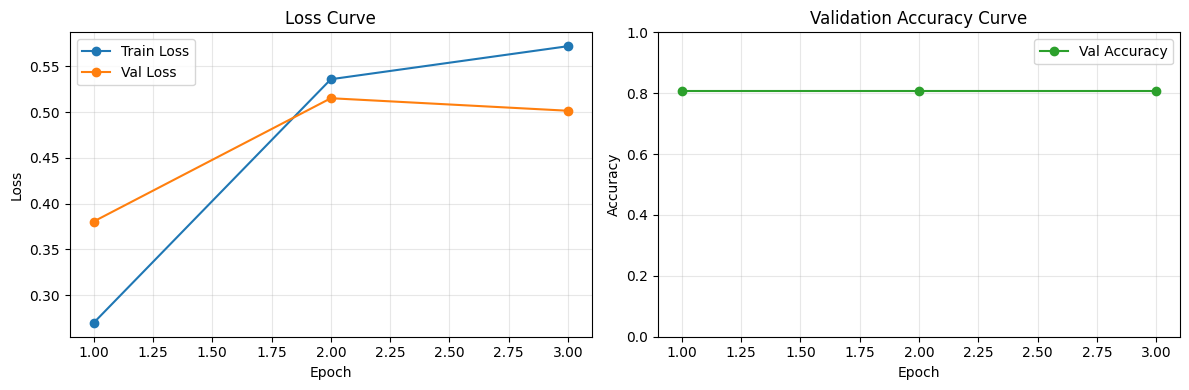

In [25]:
import matplotlib.pyplot as plt

if len(train_loss_history) == 0 or len(val_loss_history) == 0:
    print("No training history found. Run the fine-tuning cell first.")
else:
    epochs = range(1, len(train_loss_history) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, train_loss_history, marker='o', label='Train Loss')
    axes[0].plot(epochs, val_loss_history, marker='o', label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, val_acc_history, marker='o', color='tab:green', label='Val Accuracy')
    axes[1].set_title('Validation Accuracy Curve')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### B.3. Predict on the Test set

In [26]:
test_loader = DataLoader(test_tokenized, batch_size=8)

bert.eval()
all_logits = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device)
        }
        outputs = bert(**inputs)
        all_logits.append(outputs.logits.cpu())

predictions = torch.cat(all_logits, dim=0).numpy()
test_preds = np.argmax(predictions, axis=-1)

Predicting:   0%|          | 8/3241 [00:00<01:33, 34.57it/s]

Predicting: 100%|██████████| 3241/3241 [01:17<00:00, 41.97it/s]


In [27]:
if 'labels' in test_tokenized.column_names:
    y_true = np.array(test_tokenized['labels']).astype(int)
    y_pred = np.array(test_preds).astype(int)

    print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Test F1 (macro): {f1_score(y_true, y_pred, average='macro'):.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
else:
    print("No 'labels' column found in test_tokenized. Metrics cannot be computed.")

Test Accuracy: 0.8484
Test F1 (macro): 0.4590

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      3928
           1     0.8485    1.0000    0.9180     21993

    accuracy                         0.8484     25921
   macro avg     0.4242    0.5000    0.4590     25921
weighted avg     0.7199    0.8484    0.7789     25921

